# NGO Country Segmentation With Unsupervised Learning

This notebook develops an end-to-end unsupervised learning pipeline using `Country-data.csv`. The project objective is to group countries using socioeconomic and health indicators so that an NGO can identify meaningful country segments and potential aid-priority groups.

The workflow includes data exploration, preprocessing, feature engineering, PCA-based interpretation, clustering model comparison, final model selection, cluster profiling, robustness checks, and limitations.

## 1. Setup

We use three primary unsupervised clustering approaches:

- KMeans clustering
- Hierarchical Agglomerative Clustering
- Gaussian Mixture Models

PCA is used for dimensionality reduction, visualization, and interpretation. It is not treated as a replacement for clustering.

In [1]:
import itertools
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_PATH = Path("Country-data.csv")
DICTIONARY_PATH = Path("data-dictionary.csv")

sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)

## 2. Load And Describe The Dataset

The `country` column identifies each observation and is kept for interpretation only. The clustering models use the numeric development indicators.

In [2]:
df = pd.read_csv(DATA_PATH)
data_dictionary = pd.read_csv(DICTIONARY_PATH)

print(f"Dataset shape: {df.shape}")
display(df.head())

display(data_dictionary)

display(pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_values": df.isna().sum().values,
    "unique_values": df.nunique().values,
}))

Dataset shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.200,10.000,7.580,44.900,1610,9.440,56.200,5.820,553
1,Albania,16.600,28.000,6.550,48.600,9930,4.490,76.300,1.650,4090
2,Algeria,27.300,38.400,4.170,31.400,12900,16.100,76.500,2.890,4460
3,Angola,119.000,62.300,2.850,42.900,5900,22.400,60.100,6.160,3530
4,Antigua and Barbuda,10.300,45.500,6.030,58.900,19100,1.440,76.800,2.130,12200


,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services per capita. Give...
3,health,Total health spending per capita. Given as %ag...
4,imports,Imports of goods and services per capita. Give...
5,Income,Net income per person
6,Inflation,The measurement of the annual growth rate of t...
7,life_expec,The average number of years a new born child w...
8,total_fer,The number of children that would be born to e...
9,gdpp,The GDP per capita. Calculated as the Total GD...


,column,dtype,missing_values,unique_values
0,country,str,0,167
1,child_mort,float64,0,139
2,exports,float64,0,147
3,health,float64,0,147
4,imports,float64,0,151
5,income,int64,0,156
6,inflation,float64,0,156
7,life_expec,float64,0,127
8,total_fer,float64,0,138
9,gdpp,int64,0,157


## 3. Exploratory Data Analysis

This section checks quality, distributions, outliers, and correlations before modeling. These checks matter because clustering is sensitive to feature scales, skewed variables, and extreme observations.

In [3]:
print("Missing values by column:")
display(df.isna().sum().to_frame("missing_count"))

print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate country names: {df['country'].duplicated().sum()}")

display(df.describe().T)

Missing values by column:


,missing_count
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


Duplicate rows: 0
Duplicate country names: 0


,count,mean,std,min,25%,50%,75%,max
child_mort,167.000,38.270,40.329,2.600,8.250,19.300,62.100,208.000
exports,167.000,41.109,27.412,0.109,23.800,35.000,51.350,200.000
health,167.000,6.816,2.747,1.810,4.920,6.320,8.600,17.900
imports,167.000,46.890,24.210,0.066,30.200,43.300,58.750,174.000
income,167.000,17144.689,19278.068,609.000,3355.000,9960.000,22800.000,125000.000
inflation,167.000,7.782,10.571,-4.210,1.810,5.390,10.750,104.000
life_expec,167.000,70.556,8.893,32.100,65.300,73.100,76.800,82.800
total_fer,167.000,2.948,1.514,1.150,1.795,2.410,3.880,7.490
gdpp,167.000,12964.156,18328.705,231.000,1330.000,4660.000,14050.000,105000.000


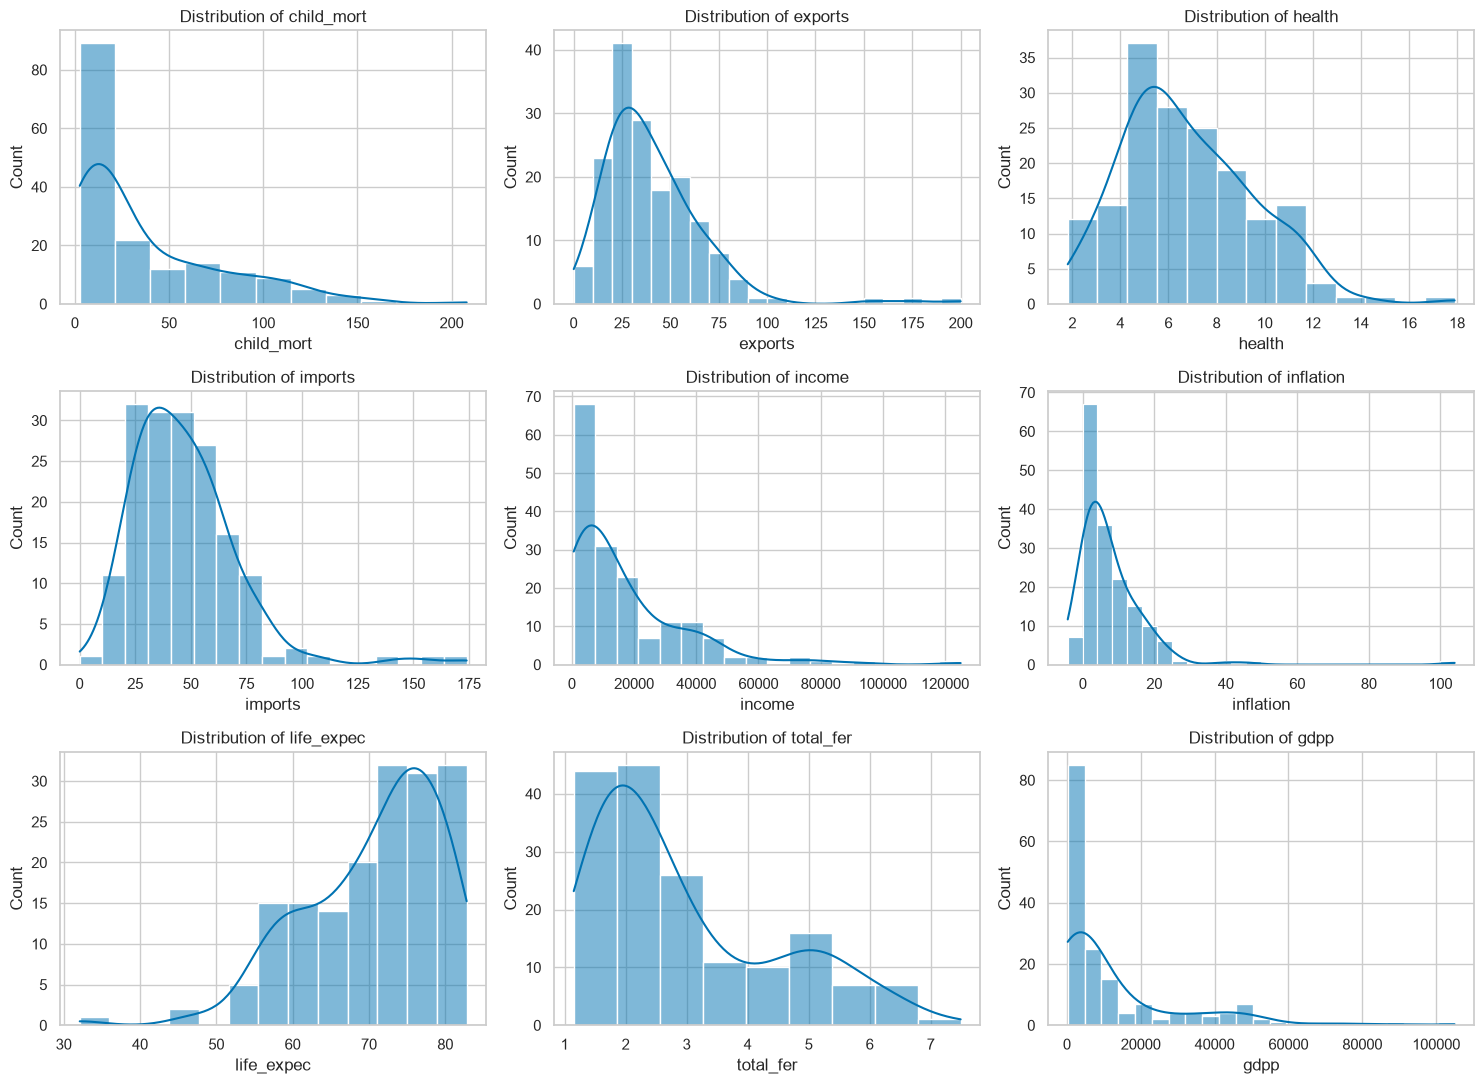

In [4]:
numeric_cols = df.drop(columns="country").columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.ravel()
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

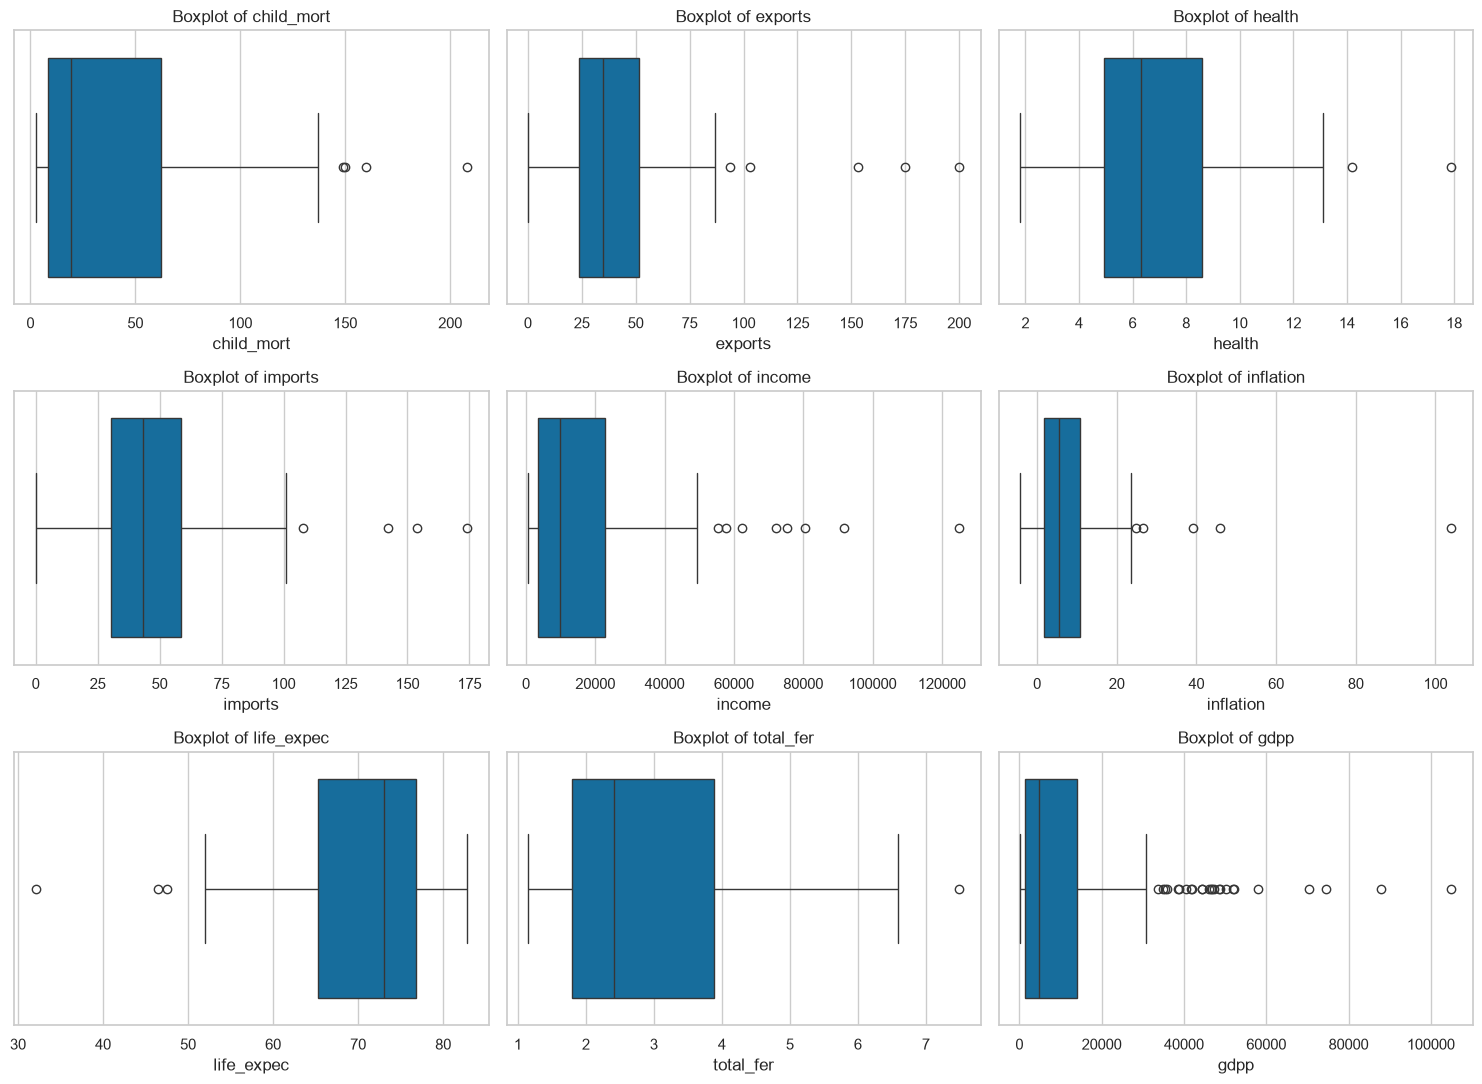

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.ravel()
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

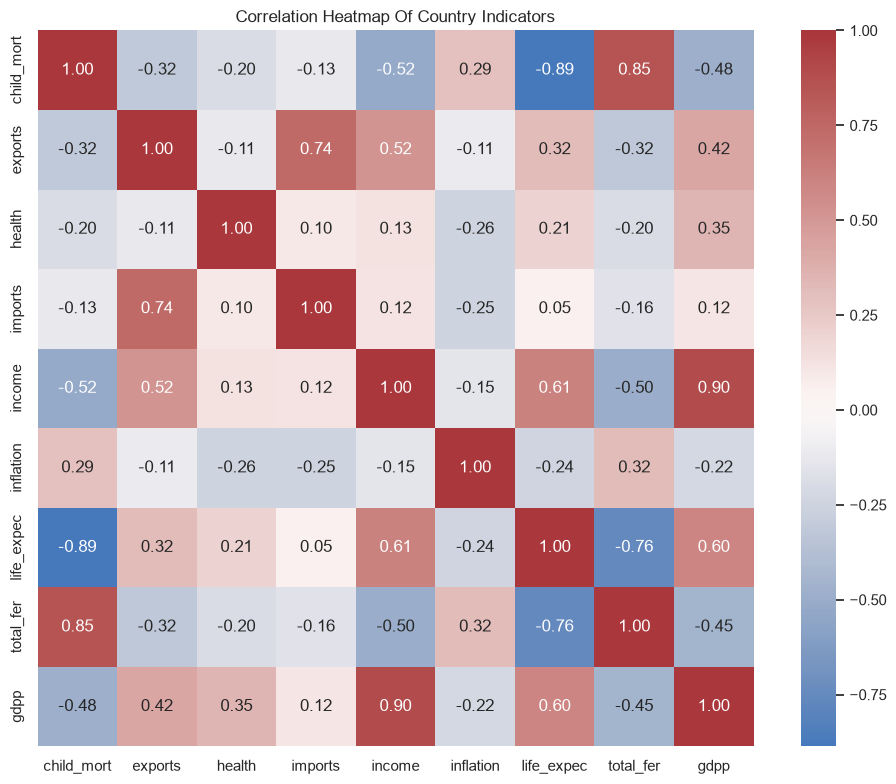

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Correlation Heatmap Of Country Indicators")
plt.tight_layout()
plt.show()

### EDA Interpretation Notes

The dataset is expected to be clean enough for modeling because it has no missing values and no duplicate country rows. The main preprocessing risks are feature scale differences, skewed economic indicators, and outliers. Outliers are not automatically removed because they may represent meaningful country profiles relevant to NGO prioritization.

## 4. Feature Engineering And Preprocessing

Three feature sets are prepared:

1. **Original scaled features**: the main modeling input.
2. **Log-adjusted features**: a robustness check for skewed `income` and `gdpp`.
3. **Engineered value features**: a robustness check that converts percentage-based export, import, and health measures into approximate per-capita values.

All model inputs are scaled with `StandardScaler` because the indicators use very different units and magnitudes.

In [7]:
feature_cols = [
    "child_mort",
    "exports",
    "health",
    "imports",
    "income",
    "inflation",
    "life_expec",
    "total_fer",
    "gdpp",
]

country_labels = df["country"].copy()
X_original = df[feature_cols].copy()

X_log = X_original.copy()
X_log["income"] = np.log1p(X_log["income"])
X_log["gdpp"] = np.log1p(X_log["gdpp"])

X_engineered = X_original.copy()
X_engineered["exports_value"] = X_engineered["exports"] * X_engineered["gdpp"] / 100
X_engineered["imports_value"] = X_engineered["imports"] * X_engineered["gdpp"] / 100
X_engineered["health_value"] = X_engineered["health"] * X_engineered["gdpp"] / 100

feature_sets_raw = {
    "original": X_original,
    "log_adjusted": X_log,
    "engineered_values": X_engineered,
}

scaled_feature_sets = {}
scalers = {}
for name, X in feature_sets_raw.items():
    scaler = StandardScaler()
    scaled_feature_sets[name] = pd.DataFrame(
        scaler.fit_transform(X),
        columns=X.columns,
        index=df.index,
    )
    scalers[name] = scaler

X_scaled = scaled_feature_sets["original"]
print("Primary modeling matrix shape:", X_scaled.shape)
display(X_scaled.head())

Primary modeling matrix shape: (167, 9)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.292,-1.138,0.279,-0.082,-0.808,0.157,-1.619,1.903,-0.679
1,-0.539,-0.480,-0.097,0.071,-0.375,-0.312,0.648,-0.860,-0.486
2,-0.273,-0.099,-0.966,-0.642,-0.221,0.789,0.670,-0.038,-0.465
3,2.008,0.775,-1.448,-0.165,-0.585,1.387,-1.179,2.128,-0.516
4,-0.696,0.161,-0.287,0.498,0.102,-0.602,0.704,-0.542,-0.042


## 5. PCA Exploration

PCA helps summarize the main dimensions of variation and provides a two-dimensional view of countries for visualization. The clustering models are still trained and evaluated separately.

,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.460,0.460
1,PC2,0.172,0.631
2,PC3,0.130,0.761
3,PC4,0.111,0.872
4,PC5,0.073,0.945
5,PC6,0.025,0.970
6,PC7,0.013,0.983
7,PC8,0.010,0.993
8,PC9,0.007,1.000


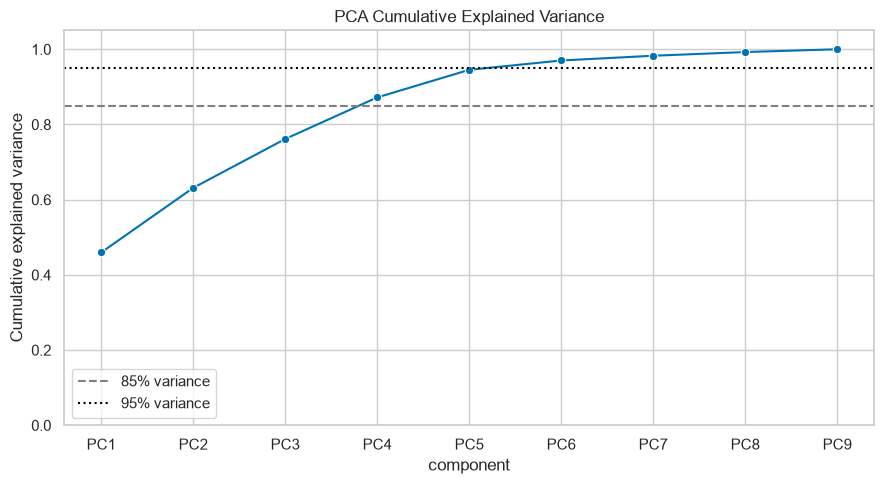

In [8]:
pca_full = PCA(random_state=RANDOM_STATE)
X_pca_full = pca_full.fit_transform(X_scaled)

pca_summary = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca_full.explained_variance_ratio_))],
    "explained_variance_ratio": pca_full.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca_full.explained_variance_ratio_),
})
display(pca_summary)

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=pca_summary,
    x="component",
    y="cumulative_explained_variance",
    marker="o",
)
plt.axhline(0.85, color="gray", linestyle="--", label="85% variance")
plt.axhline(0.95, color="black", linestyle=":", label="95% variance")
plt.ylim(0, 1.05)
plt.title("PCA Cumulative Explained Variance")
plt.ylabel("Cumulative explained variance")
plt.legend()
plt.tight_layout()
plt.show()

,PC1,PC2
life_expec,0.426,-0.223
child_mort,-0.420,0.193
total_fer,-0.404,0.155
income,0.398,0.023
gdpp,0.393,-0.046
exports,0.284,0.613
inflation,-0.193,-0.008
imports,0.161,0.672
health,0.151,-0.243


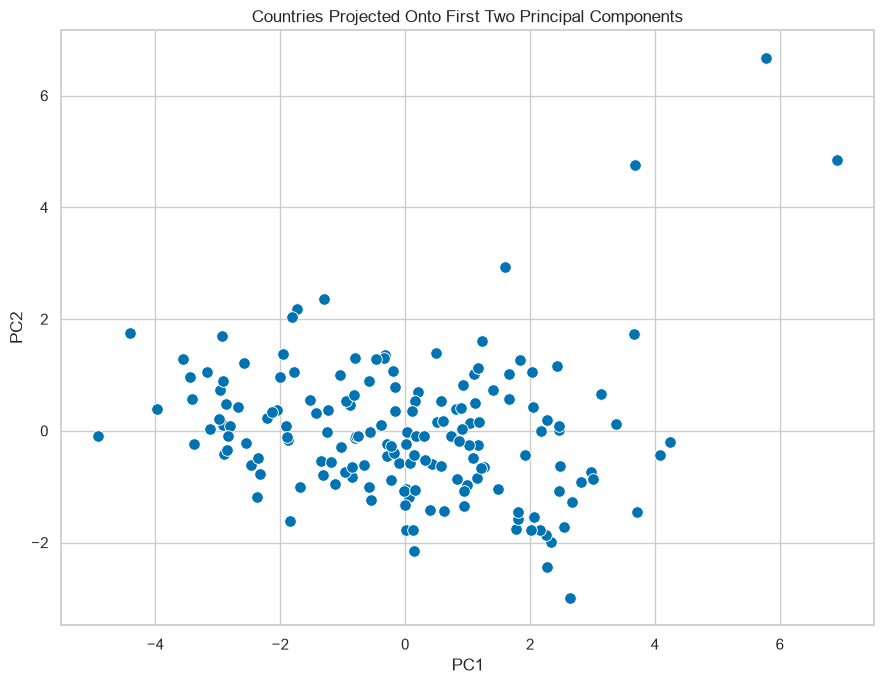

In [9]:
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2 = pd.DataFrame(
    pca_2.fit_transform(X_scaled),
    columns=["PC1", "PC2"],
    index=df.index,
)

loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=["PC1", "PC2"],
    index=feature_cols,
)
display(loadings.sort_values("PC1", key=abs, ascending=False))

plt.figure(figsize=(9, 7))
sns.scatterplot(data=X_pca_2, x="PC1", y="PC2", s=70)
plt.title("Countries Projected Onto First Two Principal Components")
plt.tight_layout()
plt.show()

## 6. Helper Functions For Model Evaluation

Because this is an unsupervised problem, there is no target variable. Model comparison uses internal validation metrics plus cluster-size balance and interpretability.

In [10]:
def cluster_size_summary(labels):
    counts = pd.Series(labels).value_counts().sort_index()
    return {
        "min_cluster_size": int(counts.min()),
        "max_cluster_size": int(counts.max()),
        "cluster_sizes": dict(counts),
    }


def evaluate_labels(X, labels):
    labels = np.asarray(labels)
    n_clusters = len(np.unique(labels))
    if n_clusters < 2 or n_clusters >= len(labels):
        return {
            "silhouette": np.nan,
            "calinski_harabasz": np.nan,
            "davies_bouldin": np.nan,
        }
    return {
        "silhouette": silhouette_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
    }


def add_common_result(results, model_name, params, X, labels, extra=None):
    metrics = evaluate_labels(X, labels)
    sizes = cluster_size_summary(labels)
    row = {
        "model": model_name,
        **params,
        **metrics,
        "min_cluster_size": sizes["min_cluster_size"],
        "max_cluster_size": sizes["max_cluster_size"],
        "cluster_sizes": sizes["cluster_sizes"],
    }
    if extra:
        row.update(extra)
    results.append(row)

## 7. KMeans Hyperparameter Tuning

KMeans is the baseline model because it produces simple, interpretable country segments. The main tuning parameter is the number of clusters.

In [11]:
kmeans_results = []
kmeans_models = {}

for n_clusters, init, n_init, max_iter in itertools.product(
    [2, 3, 4, 5, 6],
    ["k-means++", "random"],
    [10, 25, 50],
    [300, 500],
):
    model = KMeans(
        n_clusters=n_clusters,
        init=init,
        n_init=n_init,
        max_iter=max_iter,
        random_state=RANDOM_STATE,
    )
    labels = model.fit_predict(X_scaled)
    params = {
        "n_clusters": n_clusters,
        "init": init,
        "n_init": n_init,
        "max_iter": max_iter,
    }
    add_common_result(kmeans_results, "KMeans", params, X_scaled, labels, {"inertia": model.inertia_})
    kmeans_models[(n_clusters, init, n_init, max_iter)] = model

kmeans_results_df = pd.DataFrame(kmeans_results).sort_values(
    ["silhouette", "davies_bouldin"],
    ascending=[False, True],
)
display(kmeans_results_df.head(10))

  File "C:\Users\adrian\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\adrian\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\adrian\AppData\Local\Python\pythoncore-3.12-64\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\adrian\AppData\Local\Python\pythoncore-3.12-64\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\adrian\AppData\Local\Python\pythoncore-3.12-64\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi

,model,n_clusters,init,n_init,max_iter,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,max_cluster_size,cluster_sizes,inertia
30,KMeans,4,random,10,300,0.304,62.211,1.042,3,87,"{0: 48, 1: 87, 2: 3, 3: 29}",700.703
31,KMeans,4,random,10,500,0.304,62.211,1.042,3,87,"{0: 48, 1: 87, 2: 3, 3: 29}",700.703
26,KMeans,4,k-means++,25,300,0.302,62.263,1.041,3,88,"{0: 88, 1: 3, 2: 46, 3: 30}",700.392
27,KMeans,4,k-means++,25,500,0.302,62.263,1.041,3,88,"{0: 88, 1: 3, 2: 46, 3: 30}",700.392
28,KMeans,4,k-means++,50,300,0.302,62.263,1.041,3,88,"{0: 88, 1: 3, 2: 46, 3: 30}",700.392
29,KMeans,4,k-means++,50,500,0.302,62.263,1.041,3,88,"{0: 88, 1: 3, 2: 46, 3: 30}",700.392
32,KMeans,4,random,25,300,0.301,62.274,1.044,3,87,"{0: 30, 1: 47, 2: 87, 3: 3}",700.323
33,KMeans,4,random,25,500,0.301,62.274,1.044,3,87,"{0: 30, 1: 47, 2: 87, 3: 3}",700.323
34,KMeans,4,random,50,300,0.301,62.274,1.044,3,87,"{0: 30, 1: 47, 2: 87, 3: 3}",700.323
35,KMeans,4,random,50,500,0.301,62.274,1.044,3,87,"{0: 30, 1: 47, 2: 87, 3: 3}",700.323


## 8. Hierarchical Agglomerative Clustering Hyperparameter Tuning

Hierarchical clustering provides an interpretable grouping structure and a dendrogram that can support the choice of cluster count.

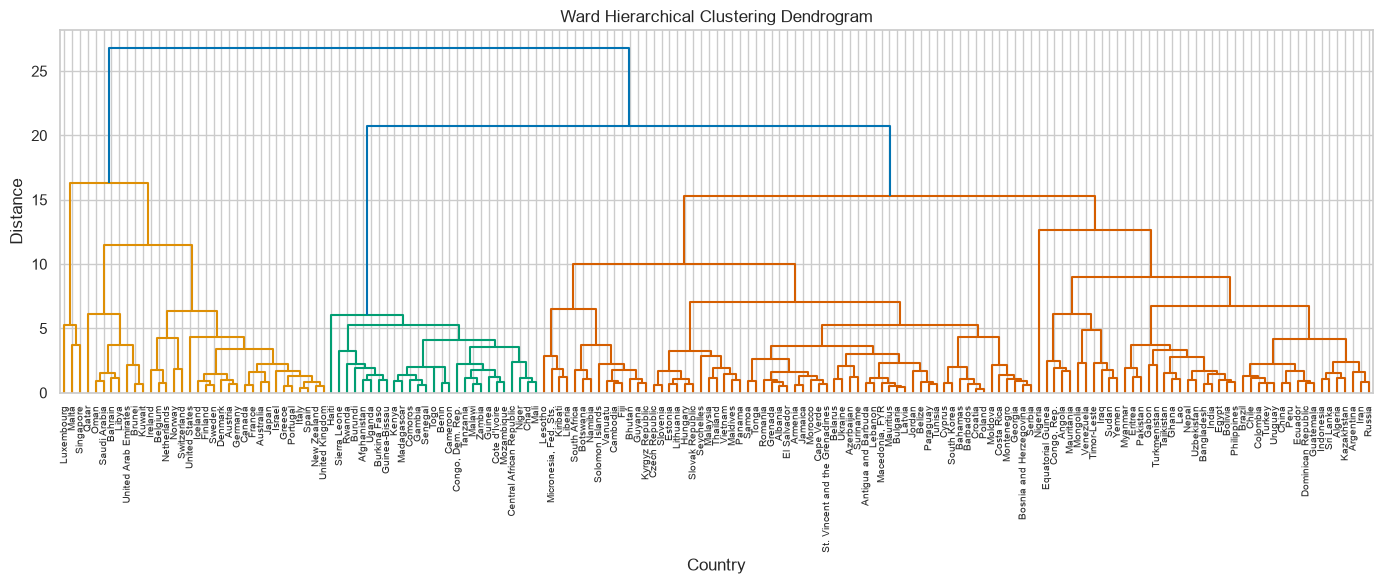

In [12]:
plt.figure(figsize=(14, 6))
ward_linkage = linkage(X_scaled, method="ward")
dendrogram(ward_linkage, labels=country_labels.values, leaf_rotation=90, leaf_font_size=7)
plt.title("Ward Hierarchical Clustering Dendrogram")
plt.xlabel("Country")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [13]:
hierarchical_results = []
hierarchical_models = {}

valid_agglomerative_configs = []
for n_clusters in [2, 3, 4, 5, 6]:
    valid_agglomerative_configs.append((n_clusters, "ward", "euclidean"))
    for linkage_method, metric in itertools.product(["complete", "average"], ["euclidean", "manhattan", "cosine"]):
        valid_agglomerative_configs.append((n_clusters, linkage_method, metric))

for n_clusters, linkage_method, metric in valid_agglomerative_configs:
    model = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage=linkage_method,
        metric=metric,
    )
    labels = model.fit_predict(X_scaled)
    params = {
        "n_clusters": n_clusters,
        "linkage": linkage_method,
        "metric": metric,
    }
    add_common_result(hierarchical_results, "Hierarchical", params, X_scaled, labels)
    hierarchical_models[(n_clusters, linkage_method, metric)] = model

hierarchical_results_df = pd.DataFrame(hierarchical_results).sort_values(
    ["silhouette", "davies_bouldin"],
    ascending=[False, True],
)
display(hierarchical_results_df.head(10))

,model,n_clusters,linkage,metric,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,max_cluster_size,cluster_sizes
4,Hierarchical,2,average,euclidean,0.630,11.391,0.264,1,166,"{0: 166, 1: 1}"
5,Hierarchical,2,average,manhattan,0.572,23.141,0.648,3,164,"{0: 164, 1: 3}"
11,Hierarchical,3,average,euclidean,0.562,18.870,0.513,1,163,"{0: 163, 1: 1, 2: 3}"
12,Hierarchical,3,average,manhattan,0.562,18.870,0.513,1,163,"{0: 163, 1: 3, 2: 1}"
18,Hierarchical,4,average,euclidean,0.497,15.305,0.470,1,162,"{0: 162, 1: 1, 2: 3, 3: 1}"
19,Hierarchical,4,average,manhattan,0.497,15.305,0.470,1,162,"{0: 162, 1: 3, 2: 1, 3: 1}"
25,Hierarchical,5,average,euclidean,0.386,13.195,0.452,1,161,"{0: 161, 1: 1, 2: 3, 3: 1, 4: 1}"
9,Hierarchical,3,complete,manhattan,0.326,43.213,1.019,3,132,"{0: 132, 1: 32, 2: 3}"
26,Hierarchical,5,average,manhattan,0.316,36.642,0.694,1,117,"{0: 45, 1: 3, 2: 1, 3: 1, 4: 117}"
0,Hierarchical,2,ward,euclidean,0.315,51.883,1.327,34,133,"{0: 133, 1: 34}"


## 9. Gaussian Mixture Model Hyperparameter Tuning

Gaussian Mixture Models provide probabilistic cluster assignments and allow more flexible cluster shapes than KMeans. AIC and BIC are used because they are designed for mixture-model comparison.

In [14]:
gmm_results = []
gmm_models = {}

for n_components, covariance_type, n_init, max_iter in itertools.product(
    [2, 3, 4, 5, 6],
    ["full", "tied", "diag", "spherical"],
    [10, 25],
    [300, 500],
):
    model = GaussianMixture(
        n_components=n_components,
        covariance_type=covariance_type,
        n_init=n_init,
        max_iter=max_iter,
        random_state=RANDOM_STATE,
    )
    labels = model.fit_predict(X_scaled)
    params = {
        "n_components": n_components,
        "covariance_type": covariance_type,
        "n_init": n_init,
        "max_iter": max_iter,
    }
    add_common_result(
        gmm_results,
        "GMM",
        params,
        X_scaled,
        labels,
        {"bic": model.bic(X_scaled), "aic": model.aic(X_scaled)},
    )
    gmm_models[(n_components, covariance_type, n_init, max_iter)] = model

gmm_results_df = pd.DataFrame(gmm_results).sort_values(
    ["bic", "silhouette"],
    ascending=[True, False],
)
display(gmm_results_df.head(10))

,model,n_components,covariance_type,n_init,max_iter,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,max_cluster_size,cluster_sizes,bic,aic
34,GMM,4,full,25,300,0.175,40.346,1.577,5,72,"{0: 5, 1: 54, 2: 72, 3: 36}",2333.466,1650.626
35,GMM,4,full,25,500,0.175,40.346,1.577,5,72,"{0: 5, 1: 54, 2: 72, 3: 36}",2333.466,1650.626
64,GMM,6,full,10,300,0.184,49.151,1.381,3,51,"{0: 51, 1: 30, 2: 37, 3: 3, 4: 40, 5: 6}",2343.752,1317.932
65,GMM,6,full,10,500,0.184,49.151,1.381,3,51,"{0: 51, 1: 30, 2: 37, 3: 3, 4: 40, 5: 6}",2343.752,1317.932
66,GMM,6,full,25,300,0.184,49.151,1.381,3,51,"{0: 51, 1: 30, 2: 37, 3: 3, 4: 40, 5: 6}",2343.752,1317.932
67,GMM,6,full,25,500,0.184,49.151,1.381,3,51,"{0: 51, 1: 30, 2: 37, 3: 3, 4: 40, 5: 6}",2343.752,1317.932
16,GMM,3,full,10,300,0.238,46.419,1.284,5,101,"{0: 61, 1: 101, 2: 5}",2429.337,1917.986
17,GMM,3,full,10,500,0.238,46.419,1.284,5,101,"{0: 61, 1: 101, 2: 5}",2429.337,1917.986
18,GMM,3,full,25,300,0.238,46.419,1.284,5,101,"{0: 61, 1: 101, 2: 5}",2429.337,1917.986
19,GMM,3,full,25,500,0.238,46.419,1.284,5,101,"{0: 61, 1: 101, 2: 5}",2429.337,1917.986


## 10. Compare Best Candidate Models

The best candidates from each model family are compared side by side. The final decision should balance metrics with interpretability and usefulness for NGO decision-making.

In [15]:
best_kmeans = kmeans_results_df.iloc[0]
best_hierarchical = hierarchical_results_df.iloc[0]
best_gmm = gmm_results_df.iloc[0]

comparison_cols = [
    "model",
    "n_clusters",
    "n_components",
    "init",
    "linkage",
    "metric",
    "covariance_type",
    "silhouette",
    "calinski_harabasz",
    "davies_bouldin",
    "bic",
    "aic",
    "min_cluster_size",
    "max_cluster_size",
    "cluster_sizes",
]

model_comparison = pd.DataFrame([best_kmeans, best_hierarchical, best_gmm])
for col in comparison_cols:
    if col not in model_comparison.columns:
        model_comparison[col] = np.nan
model_comparison = model_comparison[comparison_cols]
display(model_comparison)

,model,n_clusters,n_components,init,linkage,metric,covariance_type,silhouette,calinski_harabasz,davies_bouldin,bic,aic,min_cluster_size,max_cluster_size,cluster_sizes
30,KMeans,4.000,NaN,random,NaN,NaN,NaN,0.304,62.211,1.042,NaN,NaN,3,87,"{0: 48, 1: 87, 2: 3, 3: 29}"
4,Hierarchical,2.000,NaN,NaN,average,euclidean,NaN,0.630,11.391,0.264,NaN,NaN,1,166,"{0: 166, 1: 1}"
34,GMM,NaN,4.000,NaN,NaN,NaN,full,0.175,40.346,1.577,2333.466,1650.626,5,72,"{0: 5, 1: 54, 2: 72, 3: 36}"


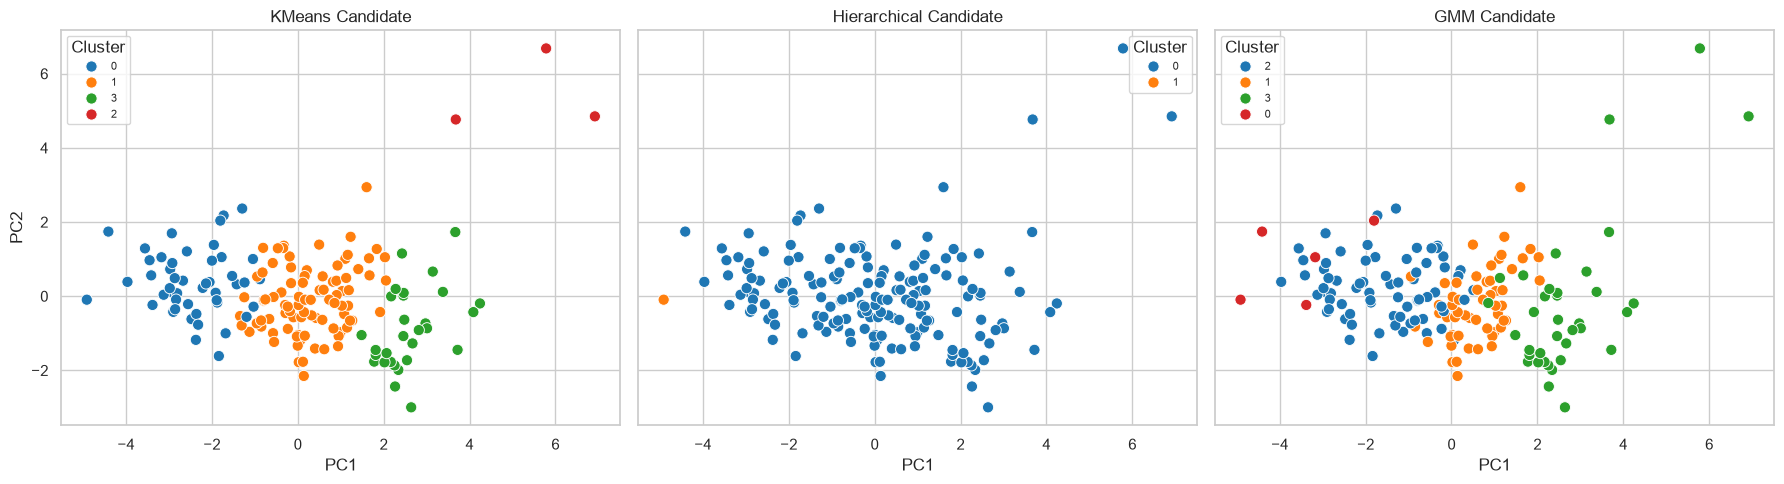

In [16]:
def labels_for_best_row(row):
    if row["model"] == "KMeans":
        key = (int(row["n_clusters"]), row["init"], int(row["n_init"]), int(row["max_iter"]))
        return kmeans_models[key].labels_
    if row["model"] == "Hierarchical":
        key = (int(row["n_clusters"]), row["linkage"], row["metric"])
        return hierarchical_models[key].fit_predict(X_scaled)
    if row["model"] == "GMM":
        key = (int(row["n_components"]), row["covariance_type"], int(row["n_init"]), int(row["max_iter"]))
        return gmm_models[key].predict(X_scaled)
    raise ValueError("Unknown model")

candidate_rows = [best_kmeans, best_hierarchical, best_gmm]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
for ax, row in zip(axes, candidate_rows):
    labels = labels_for_best_row(row)
    plot_df = X_pca_2.assign(cluster=labels.astype(str))
    sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="cluster", ax=ax, s=65, palette="tab10")
    ax.set_title(f"{row['model']} Candidate")
    ax.legend(title="Cluster", fontsize=8)
plt.tight_layout()
plt.show()

## 11. Final Model Selection

For this notebook, the final model is selected using a reproducible rule that favors interpretability for NGO stakeholders:

1. Prefer 3 or 4 clusters because these map naturally to aid-priority segments.
2. Among those candidates, prefer strong silhouette and Davies-Bouldin scores.
3. Avoid solutions with very small clusters unless they reveal a clearly meaningful country segment.
4. Use the final cluster profiles to assign descriptive NGO-facing names.

The code below chooses the best KMeans model among 3- and 4-cluster options because KMeans is transparent, easy to explain, and usually sufficient for a stakeholder-facing segmentation baseline. The comparison table above should still be used in the report to justify the choice against hierarchical clustering and GMM.

In [17]:
interpretable_kmeans = kmeans_results_df[kmeans_results_df["n_clusters"].isin([3, 4])].copy()
final_row = interpretable_kmeans.sort_values(
    ["silhouette", "davies_bouldin"],
    ascending=[False, True],
).iloc[0]

final_key = (
    int(final_row["n_clusters"]),
    final_row["init"],
    int(final_row["n_init"]),
    int(final_row["max_iter"]),
)
final_model = kmeans_models[final_key]
final_labels_raw = final_model.labels_

print("Selected final model parameters:")
display(final_row.to_frame("value"))

Selected final model parameters:


,value
model,KMeans
n_clusters,4
init,random
n_init,10
max_iter,300
silhouette,0.304
calinski_harabasz,62.211
davies_bouldin,1.042
min_cluster_size,3
max_cluster_size,87


## 12. Final Cluster Profiling And Aid-Priority Labels

Clusters are profiled using the original unscaled indicators so the results can be interpreted in real-world terms.

In [18]:
clustered_df = df.copy()
clustered_df["cluster_raw"] = final_labels_raw

cluster_profile = clustered_df.groupby("cluster_raw")[feature_cols].agg(["mean", "median"])
display(cluster_profile)

cluster_means = clustered_df.groupby("cluster_raw")[feature_cols].mean()
cluster_medians = clustered_df.groupby("cluster_raw")[feature_cols].median()
display(cluster_means)

child_mort        exports         health        imports          \
                  mean median    mean  median   mean median    mean  median   
cluster_raw                                                                   
0               92.367 89.750  28.546  23.800  6.296  5.480  41.443  39.750   
1               20.697 17.400  41.857  38.400  6.293  6.000  48.569  49.200   
2                4.133  2.800 176.000 175.000  6.793  7.770 156.667 154.000   
3                4.983  4.200  45.703  42.300  9.246  9.540  39.514  32.900   

               income           inflation        life_expec        total_fer  \
                 mean    median      mean median       mean median      mean   
cluster_raw                                                                    
0            3937.771  1900.000    11.916  8.855     59.346 59.800     4.954   
1           13275.287 10900.000     7.369  5.710     73.089 73.900     2.273   
2           64033.333 72100.000     2.468  3.620     81.433 81.300     1.380   
3           45762.069 40700.000     2.728  1.160     80.386 80.400     1.815   

                        gdpp            
            median      mean    median  
cluster_raw                             
0            5.055  1902.917   932.000  
1            2.170  7161.770  5080.000  
2            1.360 57566.667 46600.000  
3            1.870 44065.517 41900.000

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster_raw,,,,,,,,,
0,92.367,28.546,6.296,41.443,3937.771,11.916,59.346,4.954,1902.917
1,20.697,41.857,6.293,48.569,13275.287,7.369,73.089,2.273,7161.770
2,4.133,176.000,6.793,156.667,64033.333,2.468,81.433,1.380,57566.667
3,4.983,45.703,9.246,39.514,45762.069,2.728,80.386,1.815,44065.517


In [19]:
priority_score = (
    cluster_means["child_mort"].rank(ascending=True)
    + cluster_means["total_fer"].rank(ascending=True)
    + cluster_means["inflation"].rank(ascending=True)
    + cluster_means["income"].rank(ascending=False)
    + cluster_means["gdpp"].rank(ascending=False)
    + cluster_means["life_expec"].rank(ascending=False)
)

priority_order = priority_score.sort_values(ascending=False).index.tolist()
base_names = [
    "High Aid Priority",
    "Moderate Aid Priority",
    "Lower Aid Priority",
    "Specialized Review Group",
    "Lowest Aid Priority",
    "Additional Segment",
]
cluster_name_map = {cluster: base_names[i] for i, cluster in enumerate(priority_order)}

clustered_df["aid_priority_segment"] = clustered_df["cluster_raw"].map(cluster_name_map)
clustered_df["cluster"] = clustered_df["aid_priority_segment"]

print("Cluster naming map:")
display(pd.DataFrame({
    "cluster_raw": list(cluster_name_map.keys()),
    "aid_priority_segment": list(cluster_name_map.values()),
}).sort_values("cluster_raw"))

display(clustered_df[["country", "cluster_raw", "aid_priority_segment"] + feature_cols].sort_values(["aid_priority_segment", "country"]))

Cluster naming map:


,cluster_raw,aid_priority_segment
0,0,High Aid Priority
1,1,Moderate Aid Priority
3,2,Specialized Review Group
2,3,Lower Aid Priority


,country,cluster_raw,aid_priority_segment,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,0,High Aid Priority,90.200,10.000,7.580,44.900,1610,9.440,56.200,5.820,553
3,Angola,0,High Aid Priority,119.000,62.300,2.850,42.900,5900,22.400,60.100,6.160,3530
17,Benin,0,High Aid Priority,111.000,23.800,4.100,37.200,1820,0.885,61.800,5.360,758
21,Botswana,0,High Aid Priority,52.500,43.600,8.300,51.300,13300,8.920,57.100,2.880,6350
25,Burkina Faso,0,High Aid Priority,116.000,19.200,6.740,29.600,1430,6.810,57.900,5.870,575
...,...,...,...,...,...,...,...,...,...,...,...,...
163,Venezuela,1,Moderate Aid Priority,17.100,28.500,4.910,17.600,16500,45.900,75.400,2.470,13500
164,Vietnam,1,Moderate Aid Priority,23.300,72.000,6.840,80.200,4490,12.100,73.100,1.950,1310
91,Luxembourg,2,Specialized Review Group,2.800,175.000,7.770,142.000,91700,3.620,81.300,1.630,105000
98,Malta,2,Specialized Review Group,6.800,153.000,8.650,154.000,28300,3.830,80.300,1.360,21100


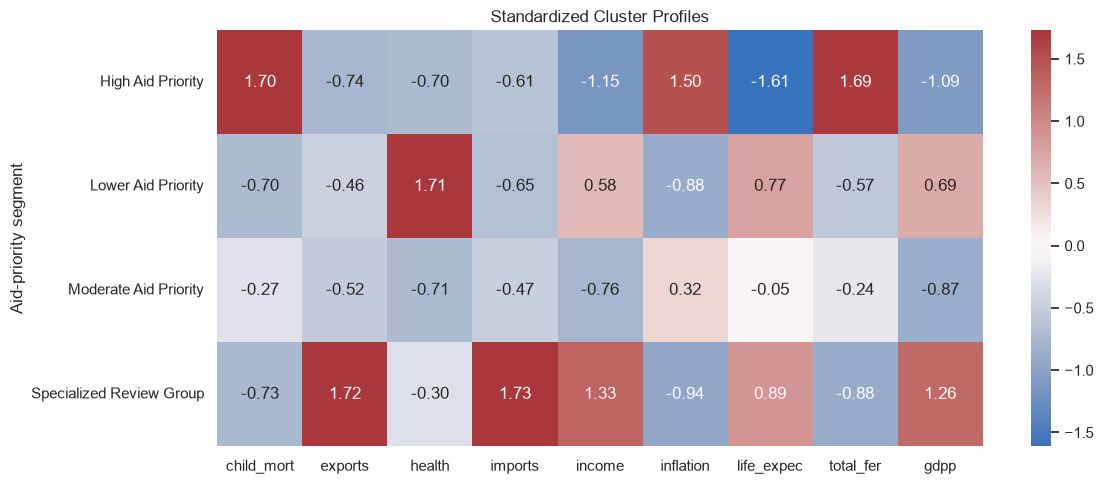

In [20]:
profile_for_plot = clustered_df.groupby("aid_priority_segment")[feature_cols].mean()
profile_scaled = pd.DataFrame(
    StandardScaler().fit_transform(profile_for_plot),
    index=profile_for_plot.index,
    columns=profile_for_plot.columns,
)

plt.figure(figsize=(12, 5))
sns.heatmap(profile_scaled, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Standardized Cluster Profiles")
plt.ylabel("Aid-priority segment")
plt.tight_layout()
plt.show()

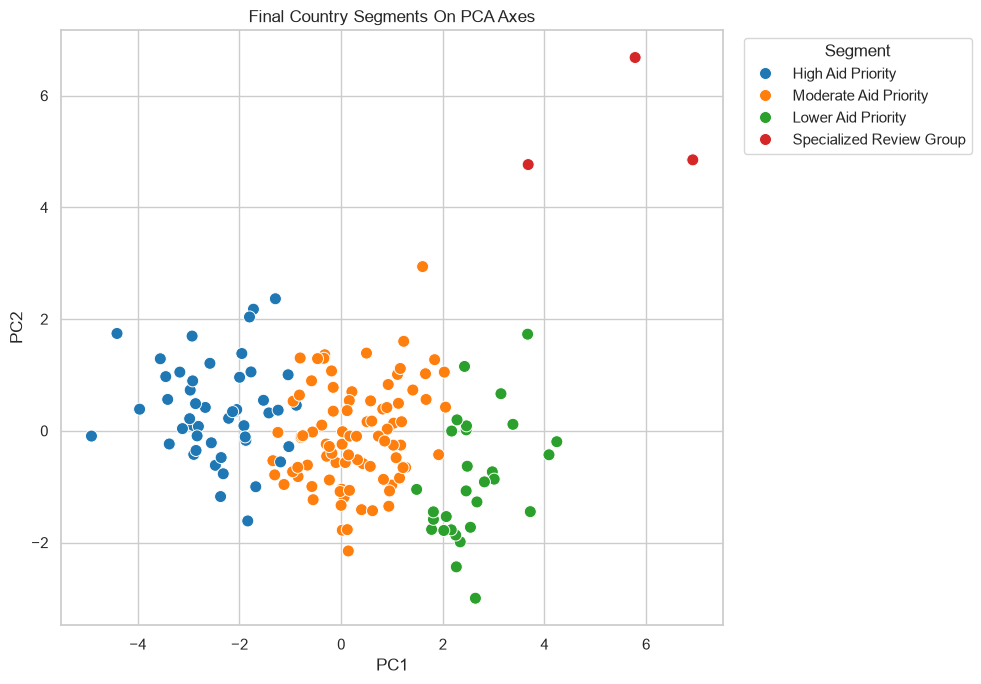

In [21]:
plot_df = X_pca_2.copy()
plot_df["aid_priority_segment"] = clustered_df["aid_priority_segment"]
plot_df["country"] = clustered_df["country"]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="aid_priority_segment",
    s=75,
    palette="tab10",
)
plt.title("Final Country Segments On PCA Axes")
plt.legend(title="Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

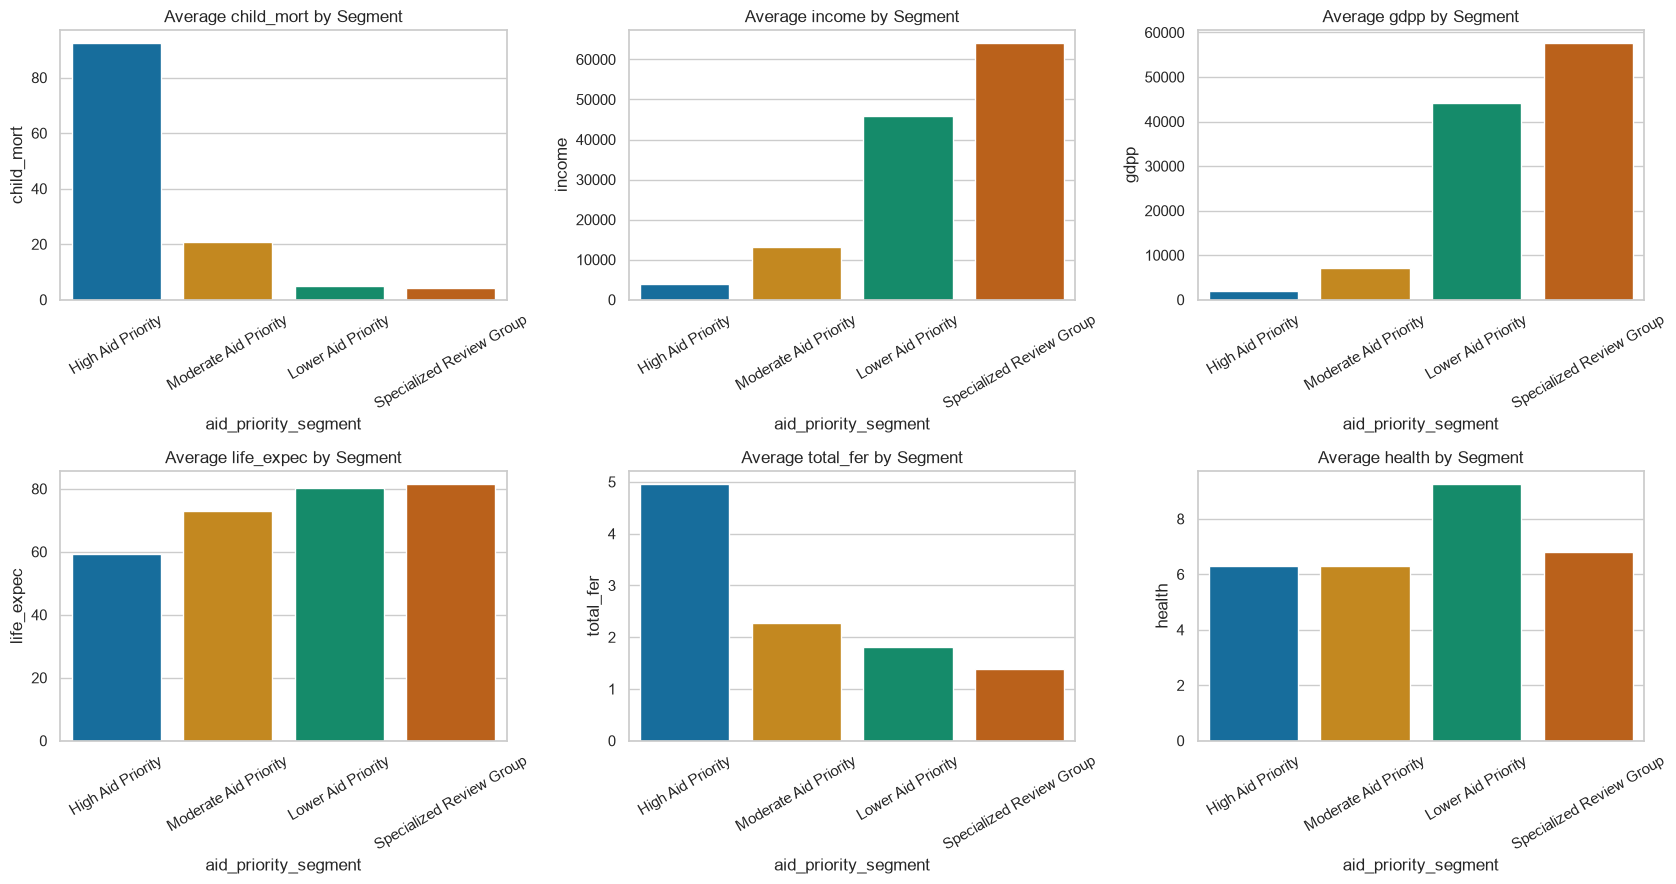

In [22]:
key_indicators = ["child_mort", "income", "gdpp", "life_expec", "total_fer", "health"]
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.ravel()
for ax, col in zip(axes, key_indicators):
    sns.barplot(
        data=clustered_df,
        x="aid_priority_segment",
        y=col,
        estimator="mean",
        errorbar=None,
        ax=ax,
        palette="colorblind",
    )
    ax.set_title(f"Average {col} by Segment")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [23]:
high_priority = clustered_df[clustered_df["aid_priority_segment"] == "High Aid Priority"].sort_values(
    ["child_mort", "income", "gdpp"],
    ascending=[False, True, True],
)

print(f"Countries in the High Aid Priority segment: {len(high_priority)}")
display(high_priority[["country", "child_mort", "income", "gdpp", "life_expec", "total_fer", "health"]])

Countries in the High Aid Priority segment: 48


,country,child_mort,income,gdpp,life_expec,total_fer,health
66,Haiti,208.000,1500,662,32.100,3.330,6.910
132,Sierra Leone,160.000,1220,399,55.000,5.200,13.100
32,Chad,150.000,1930,897,56.500,6.590,4.530
31,Central African Republic,149.000,888,446,47.500,5.210,3.980
97,Mali,137.000,1870,708,59.500,6.550,4.980
113,Nigeria,130.000,5150,2330,60.500,5.840,5.070
112,Niger,123.000,814,348,58.800,7.490,5.160
3,Angola,119.000,5900,3530,60.100,6.160,2.850
37,"Congo, Dem. Rep.",116.000,609,334,57.500,6.540,7.910
25,Burkina Faso,116.000,1430,575,57.900,5.870,6.740


### Final Model Interpretation Template

Use the cluster profile tables and visuals above to write the report findings. A strong interpretation should explain:

- which segment has the highest child mortality and fertility
- which segment has the lowest income and GDP per capita
- which segment has the lowest life expectancy
- whether any segment appears economically wealthy but still unusual on trade, inflation, or health indicators
- why the high-priority segment is operationally relevant for NGO screening

## 13. Robustness Checks

The final model choice is checked against alternative preprocessing choices. The goal is not to replace the final analysis, but to see whether the broad segmentation remains plausible when skewness and engineered value features are handled differently.

In [24]:
def best_kmeans_for_matrix(X, allowed_clusters=(3, 4)):
    rows = []
    models = {}
    for n_clusters, init, n_init in itertools.product(allowed_clusters, ["k-means++"], [25, 50]):
        model = KMeans(
            n_clusters=n_clusters,
            init=init,
            n_init=n_init,
            max_iter=500,
            random_state=RANDOM_STATE,
        )
        labels = model.fit_predict(X)
        row = {
            "n_clusters": n_clusters,
            "init": init,
            "n_init": n_init,
            "max_iter": 500,
            **evaluate_labels(X, labels),
            **cluster_size_summary(labels),
        }
        rows.append(row)
        models[(n_clusters, init, n_init, 500)] = (model, labels)
    result_df = pd.DataFrame(rows).sort_values(["silhouette", "davies_bouldin"], ascending=[False, True])
    best = result_df.iloc[0]
    key = (int(best["n_clusters"]), best["init"], int(best["n_init"]), int(best["max_iter"]))
    return best, models[key][1]

robustness_rows = []
robustness_labels = {}

for feature_set_name, X_variant in scaled_feature_sets.items():
    best, labels = best_kmeans_for_matrix(X_variant)
    robustness_rows.append({"feature_set": feature_set_name, **best.to_dict()})
    robustness_labels[feature_set_name] = labels

n_components_85 = int(np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.85) + 1)
X_pca_85 = pd.DataFrame(
    PCA(n_components=n_components_85, random_state=RANDOM_STATE).fit_transform(X_scaled),
    index=df.index,
)
best_pca, labels_pca = best_kmeans_for_matrix(X_pca_85)
robustness_rows.append({"feature_set": f"pca_{n_components_85}_components", **best_pca.to_dict()})
robustness_labels[f"pca_{n_components_85}_components"] = labels_pca

robustness_df = pd.DataFrame(robustness_rows)
display(robustness_df[[
    "feature_set",
    "n_clusters",
    "silhouette",
    "calinski_harabasz",
    "davies_bouldin",
    "min_cluster_size",
    "max_cluster_size",
    "cluster_sizes",
]])

,feature_set,n_clusters,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,max_cluster_size,cluster_sizes
0,original,4,0.302,62.263,1.041,3,88,"{0: 88, 1: 3, 2: 46, 3: 30}"
1,log_adjusted,4,0.254,67.323,1.148,3,64,"{0: 3, 1: 64, 2: 62, 3: 38}"
2,engineered_values,4,0.317,75.401,1.009,2,88,"{0: 47, 1: 30, 2: 88, 3: 2}"
3,pca_4_components,4,0.355,84.144,0.904,3,87,"{0: 87, 1: 3, 2: 48, 3: 29}"


## 14. Key Findings For The Report

Use the outputs above to complete the final report narrative. The key findings should be based on the final cluster profiles, but the expected structure is:

1. The countries separate meaningfully by broad development and health conditions.
2. The highest-priority segment should show the greatest humanitarian concern: high child mortality, low income, low GDP per capita, lower life expectancy, and high fertility.
3. PCA helps show that much of the variation is driven by a general development axis.
4. KMeans provides a transparent segmentation that is easier for NGO stakeholders to interpret than more complex alternatives.
5. The final clusters are useful for strategic screening, not for making final aid-allocation decisions without additional context.

## 15. Limitations And Future Work

This analysis has several limitations:

- The data is cross-sectional and does not show whether countries are improving or deteriorating.
- Country-level averages hide regional inequality and vulnerable subpopulations.
- The dataset lacks direct measures of poverty, conflict, governance, education, food security, climate risk, and NGO operating constraints.
- Several indicators are correlated, so clustering may mainly reflect a broad development-level dimension.
- Clustering validation is imperfect because there are no true labels.
- KMeans assumes compact clusters, hierarchical clustering depends on linkage and distance choices, and GMM assumes mixture distributions that may not fully represent socioeconomic patterns.
- PCA is useful for visualization but can oversimplify country differences.
- The results should support strategic prioritization and further investigation, not final funding decisions.

Future work should incorporate more recent data, time-series indicators, subnational measures, and operational variables relevant to NGO planning.